# News Classification - NLP Pipeline

## Projet de Classification d'Articles d'Actualité

Ce notebook implémente une pipeline NLP complète pour classifier automatiquement les articles d'actualité en 4 catégories :
- **World** (0) : Actualités mondiales
- **Sports** (1) : Sports
- **Business** (2) : Affaires et économie
- **Sci/Tech** (3) : Science et technologie

### Étapes du pipeline :
1. Chargement des données depuis Hugging Face (SetFit/ag_news)
2. Conversion en DataFrame pandas
3. Analyse exploratoire des données (EDA)
4. Prétraitement des textes
5. Génération des embeddings avec Sentence Transformers

In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# Bibliothèques NLP
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import nltk

# Télécharger les stopwords
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

# Configuration de l'affichage
sns.set(style='whitegrid')
pd.set_option('display.max_colwidth', 100)
print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\redaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\redaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1. Chargement des Données depuis Hugging Face

Nous utilisons le dataset **SetFit/ag_news** qui contient des articles d'actualité classés en 4 catégories.

In [ ]:
# Chargement du dataset depuis Hugging Face
print("⏳ Chargement du dataset SetFit/ag_news...")
dataset = load_dataset("SetFit/ag_news")

# Afficher la structure du dataset
print(" Structure du dataset:")
print(dataset)

# Afficher les splits disponibles
print("\n📁 Splits disponibles:", list(dataset.keys()))

⏳ Chargement du dataset SetFit/ag_news...

📊 Structure du dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})

📁 Splits disponibles: ['train', 'test']

📊 Structure du dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})

📁 Splits disponibles: ['train', 'test']


## 2. Conversion en DataFrame Pandas

In [ ]:
# Conversion du dataset en DataFrame pandas
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

# Combiner train et test pour l'analyse (optionnel)
df = pd.concat([df_train, df_test], ignore_index=True)

# Mapping des labels numériques vers les noms de catégories
label_mapping = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
df['category'] = df['label'].map(label_mapping)

print(f" Dimensions du DataFrame:")
print(f"   - Train: {len(df_train)} articles")
print(f"   - Test: {len(df_test)} articles")
print(f"   - Total: {len(df)} articles")

print("\n Colonnes disponibles:", df.columns.tolist())
print("\n Aperçu des données:")
df.head()

📊 Dimensions du DataFrame:
   - Train: 120000 articles
   - Test: 7600 articles
   - Total: 127600 articles

📝 Colonnes disponibles: ['text', 'label', 'label_text', 'category']

🔍 Aperçu des données:


,text,label,label_text,category
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindli...",2,Business,Business
1,Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Gr...,2,Business,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\abou...,2,Business,Business
3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted o...,2,Business,Business
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world o...",2,Business,Business


## 3. Analyse Exploratoire des Données (EDA)

### 3.1 Informations générales sur le dataset

In [ ]:
# Informations sur le DataFrame


df.info()

print("\n📊 Statistiques descriptives:")
df.describe(include='all')

📋 Informations sur le DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        127600 non-null  object
 1   label       127600 non-null  int64 
 2   label_text  127600 non-null  object
 3   category    127600 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.9+ MB

📊 Statistiques descriptives:


,text,label,label_text,category
count,127600,127600.000000,127600,127600
unique,127600,NaN,4,4
top,Right-hander must pass physical Right-hander Matt Clement and the Boston Red Sox agreed Friday t...,NaN,Business,Business
freq,1,NaN,31900,31900
mean,NaN,1.500000,NaN,NaN
std,NaN,1.118038,NaN,NaN
min,NaN,0.000000,NaN,NaN
25%,NaN,0.750000,NaN,NaN
50%,NaN,1.500000,NaN,NaN
75%,NaN,2.250000,NaN,NaN


In [5]:
# Vérification des valeurs manquantes
print("🔍 Valeurs manquantes par colonne:")
missing_values = df.isnull().sum()
print(missing_values)

# Vérification des doublons
duplicates = df.duplicated(subset=['text']).sum()
print(f"\n🔄 Nombre de doublons (basé sur le texte): {duplicates}")

🔍 Valeurs manquantes par colonne:
text          0
label         0
label_text    0
category      0
dtype: int64

🔄 Nombre de doublons (basé sur le texte): 0


### 3.2 Distribution des catégories

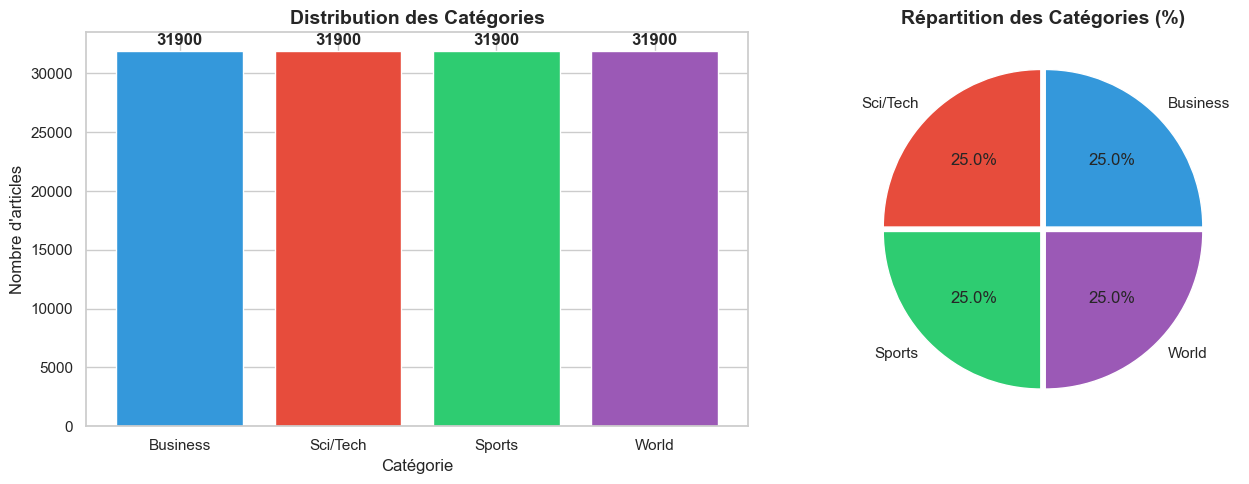


📊 Répartition des catégories:
category
Business    31900
Sci/Tech    31900
Sports      31900
World       31900
Name: count, dtype: int64


In [6]:
# Distribution des catégories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
category_counts = df['category'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
axes[0].bar(category_counts.index, category_counts.values, color=colors)
axes[0].set_title('Distribution des Catégories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre d\'articles')
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Graphique en camembert
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=[0.02]*4)
axes[1].set_title('Répartition des Catégories (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Répartition des catégories:")
print(category_counts)

### 3.3 Analyse de la longueur des textes

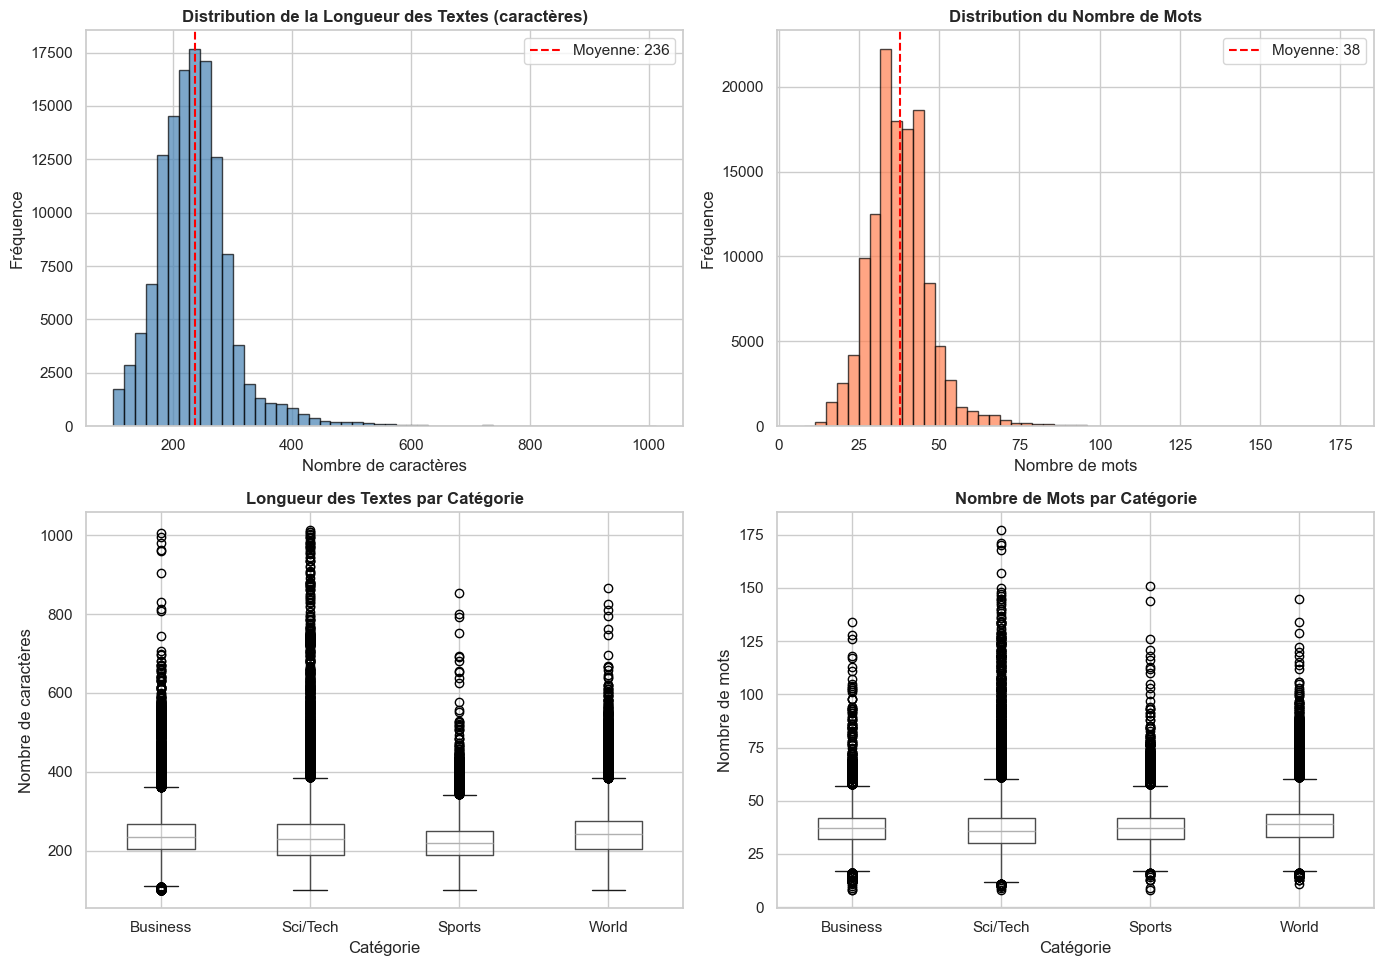


📊 Statistiques sur la longueur des textes:
         text_length     word_count
count  127600.000000  127600.000000
mean      236.407343      37.840000
std        66.438756      10.087912
min       100.000000       8.000000
25%       196.000000      32.000000
50%       232.000000      37.000000
75%       266.000000      43.000000
max      1012.000000     177.000000


In [7]:
# Analyse de la longueur des textes
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution de la longueur des caractères
axes[0, 0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution de la Longueur des Textes (caractères)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nombre de caractères')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["text_length"].mean():.0f}')
axes[0, 0].legend()

# Distribution du nombre de mots
axes[0, 1].hist(df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution du Nombre de Mots', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de mots')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["word_count"].mean():.0f}')
axes[0, 1].legend()

# Boxplot par catégorie (longueur)
df.boxplot(column='text_length', by='category', ax=axes[1, 0])
axes[1, 0].set_title('Longueur des Textes par Catégorie', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Catégorie')
axes[1, 0].set_ylabel('Nombre de caractères')
plt.suptitle('')

# Boxplot par catégorie (mots)
df.boxplot(column='word_count', by='category', ax=axes[1, 1])
axes[1, 1].set_title('Nombre de Mots par Catégorie', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Catégorie')
axes[1, 1].set_ylabel('Nombre de mots')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n📊 Statistiques sur la longueur des textes:")
print(df[['text_length', 'word_count']].describe())

### 3.4 Analyse des mots les plus fréquents

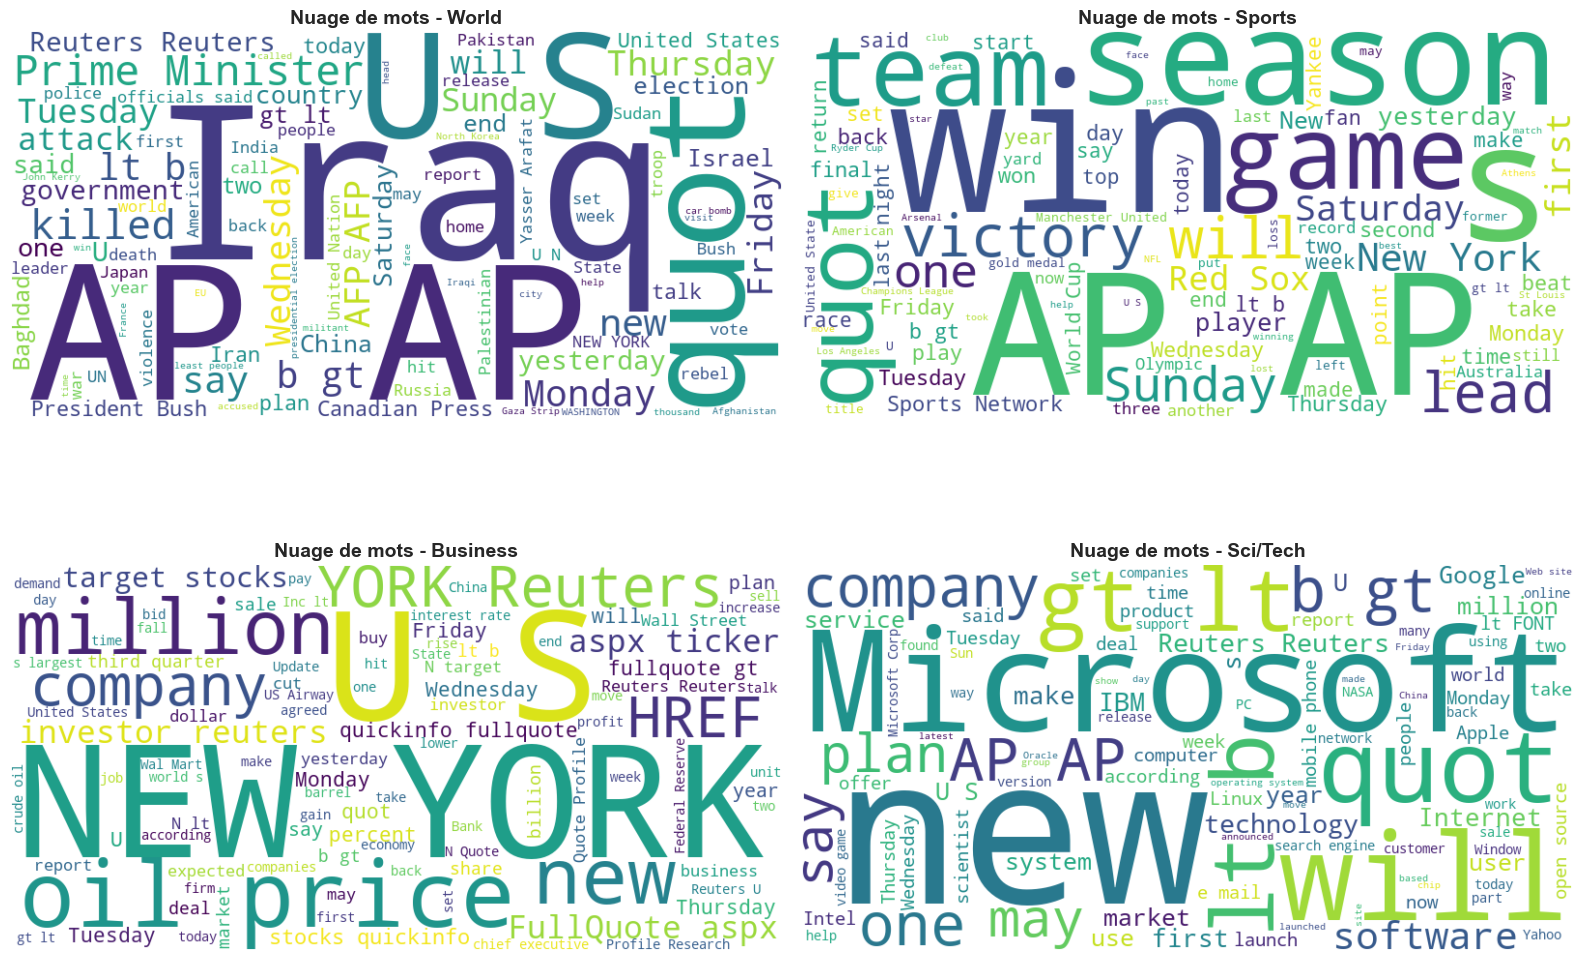

In [8]:
# Analyse des mots les plus fréquents par catégorie
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, category in enumerate(label_mapping.values()):
    text = ' '.join(df[df['category'] == category]['text'].tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          max_words=100, colormap='viridis').generate(text)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Nuage de mots - {category}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### ⚠️ Important: Minimal Preprocessing for Embeddings

**Why we DON'T remove stopwords or punctuation:**

Sentence Transformers (like `paraphrase-multilingual-MiniLM-L12-v2`) work best with **natural text**:
- They have their own tokenizer that handles punctuation
- Stopwords carry semantic meaning: "This is **NOT** good" ≠ "good"
- Heavy preprocessing can **HURT** embedding quality

**What we do:**
- ✅ Remove duplicates (data quality)
- ✅ Clean whitespace (formatting)
- ✅ Handle empty values

**What we DON'T do:**
- ❌ Remove stopwords
- ❌ Remove punctuation  
- ❌ Lowercase (model handles it)
- ❌ Stemming/Lemmatization

In [9]:
# Minimal preprocessing function for Sentence Transformer embeddings

def preprocess_text(text):
    """
    Minimal text cleaning for embedding models.
    
    We ONLY clean whitespace - preserving all semantic content.
    Sentence Transformers work best with natural text!
    """
    if not isinstance(text, str) or not text:
        return ""
    
    # Only clean excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Demonstrate why minimal preprocessing is better
print("=" * 60)
print("WHY MINIMAL PREPROCESSING FOR EMBEDDINGS?")
print("=" * 60)

sample_text = df['text'].iloc[0]
print("\n📝 Original text:")
print(sample_text)
print("\n✅ Cleaned text (minimal - for embeddings):")
print(preprocess_text(sample_text))

# Show dangerous example
dangerous_example = "This movie is NOT good at all!"
print("\n" + "=" * 60)
print("⚠️ DANGER OF HEAVY PREPROCESSING:")
print("=" * 60)
print(f"\nOriginal: '{dangerous_example}'")
print(f"Minimal (correct): '{preprocess_text(dangerous_example)}'")

# What old approach would do (DON'T USE THIS)
old_way = "movie good"  # After stopword + punctuation removal
print(f"Heavy preprocessing (WRONG): '{old_way}'")
print("\n❌ Heavy preprocessing REVERSED the meaning!")

WHY MINIMAL PREPROCESSING FOR EMBEDDINGS?

📝 Original text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

✅ Cleaned text (minimal - for embeddings):
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

⚠️ DANGER OF HEAVY PREPROCESSING:

Original: 'This movie is NOT good at all!'
Minimal (correct): 'This movie is NOT good at all!'
Heavy preprocessing (WRONG): 'movie good'

❌ Heavy preprocessing REVERSED the meaning!


In [10]:
# Suppression des doublons
print(f"📊 Nombre d'articles avant suppression des doublons: {len(df)}")
df_clean = df.drop_duplicates(subset=['text'], keep='first').copy()
print(f"✅ Nombre d'articles après suppression des doublons: {len(df_clean)}")
print(f"🗑️ Doublons supprimés: {len(df) - len(df_clean)}")

📊 Nombre d'articles avant suppression des doublons: 127600
✅ Nombre d'articles après suppression des doublons: 127600
🗑️ Doublons supprimés: 0


In [11]:
# Apply minimal preprocessing to all texts
print("⏳ Applying minimal preprocessing (whitespace only)...")
df_clean['text_clean'] = df_clean['text'].apply(preprocess_text)

# Remove any empty texts
empty_count = (df_clean['text_clean'] == "").sum()
if empty_count > 0:
    df_clean = df_clean[df_clean['text_clean'] != ""]
    print(f"   Removed {empty_count} empty texts")

print("✅ Preprocessing complete!")
print(f"   Total articles: {len(df_clean)}")

# Show examples
print("\n📝 Sample preprocessed texts:")
for i in range(3):
    print(f"\n--- Article {i+1} [{df_clean['category'].iloc[i]}] ---")
    print(f"{df_clean['text_clean'].iloc[i][:150]}...")

⏳ Applying minimal preprocessing (whitespace only)...
✅ Preprocessing complete!
   Total articles: 127600

📝 Sample preprocessed texts:

--- Article 1 [Business] ---
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

--- Article 2 [Business] ---
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and ...

--- Article 3 [Business] ---
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expecte...
✅ Preprocessing complete!
   Total articles: 127600

📝 Sample preprocessed texts:

--- Article 1 [Business] ---
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....

--- Article 2 [Business] ---
Carlyle Looks Toward Commerc

In [12]:
# Verify text lengths are preserved (minimal preprocessing)
df_clean['clean_text_length'] = df_clean['text_clean'].apply(len)
df_clean['clean_word_count'] = df_clean['text_clean'].apply(lambda x: len(x.split()))

print("📊 Text Statistics (should be nearly identical with minimal preprocessing):")
print(f"   Original - Avg length: {df_clean['text_length'].mean():.0f} chars, Avg words: {df_clean['word_count'].mean():.0f}")
print(f"   Cleaned  - Avg length: {df_clean['clean_text_length'].mean():.0f} chars, Avg words: {df_clean['clean_word_count'].mean():.0f}")

# Small difference is expected (whitespace cleanup only)
length_diff = abs(df_clean['text_length'].mean() - df_clean['clean_text_length'].mean())
print(f"\n✅ Difference: {length_diff:.1f} characters (whitespace cleanup only)")
print("   This confirms we're preserving semantic content for embeddings!")

📊 Text Statistics (should be nearly identical with minimal preprocessing):
   Original - Avg length: 236 chars, Avg words: 38
   Cleaned  - Avg length: 236 chars, Avg words: 38

✅ Difference: 0.6 characters (whitespace cleanup only)
   This confirms we're preserving semantic content for embeddings!


## 5. Generating Embeddings with Sentence Transformers

We use the **paraphrase-multilingual-MiniLM-L12-v2** model to generate vector representations (embeddings).

**Why this model?**
- Multilingual support (50+ languages)
- 384-dimensional embeddings (efficient)
- High-quality semantic representations
- Works directly with natural text (no heavy preprocessing needed!)

In [13]:
# Load Sentence Transformer model
print("⏳ Loading model: paraphrase-multilingual-MiniLM-L12-v2...")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("✅ Model loaded successfully!")

# Display model info
embedding_dim = model.get_sentence_embedding_dimension()
print(f"\n📊 Model Information:")
print(f"   - Embedding dimension: {embedding_dim}")
print(f"   - Model type: Sentence Transformer (BERT-based)")
print(f"   - Input: Natural text (no heavy preprocessing needed)")

⏳ Loading model: paraphrase-multilingual-MiniLM-L12-v2...
✅ Model loaded successfully!

📊 Model Information:
   - Embedding dimension: 384
   - Model type: Sentence Transformer (BERT-based)
   - Input: Natural text (no heavy preprocessing needed)
✅ Model loaded successfully!

📊 Model Information:
   - Embedding dimension: 384
   - Model type: Sentence Transformer (BERT-based)
   - Input: Natural text (no heavy preprocessing needed)


In [14]:
# Generate embeddings for a sample (for demonstration)
# Note: Full dataset would take longer

sample_size = 1000
df_sample = df_clean.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"⏳ Generating embeddings for {sample_size} articles...")
print(f"   Using cleaned text (minimal preprocessing - preserves meaning)")

embeddings = model.encode(
    df_sample['text_clean'].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\n✅ Embeddings generated successfully!")
print(f"📊 Embeddings shape: {embeddings.shape}")
print(f"   - Number of articles: {embeddings.shape[0]}")
print(f"   - Vector dimension: {embeddings.shape[1]}")

# Store labels for later use
labels = df_sample['label'].values
categories = df_sample['category'].values
print(f"\n📋 Labels stored: {len(labels)} (for ML training)")

⏳ Generating embeddings for 1000 articles...
   Using cleaned text (minimal preprocessing - preserves meaning)


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


✅ Embeddings generated successfully!
📊 Embeddings shape: (1000, 384)
   - Number of articles: 1000
   - Vector dimension: 384

📋 Labels stored: 1000 (for ML training)


⏳ Reducing dimensions with t-SNE (this may take a minute)...


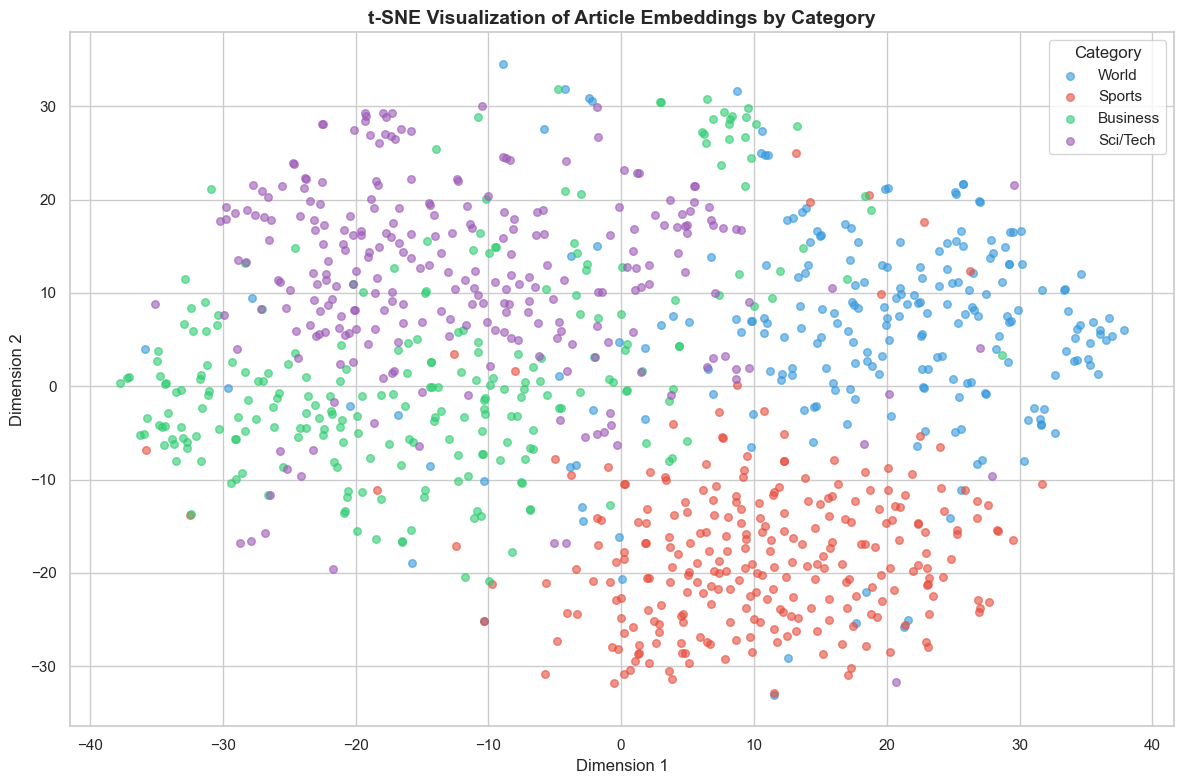


✅ Visualization complete!
   Notice how articles of the same category tend to cluster together!
   This shows the embeddings capture semantic meaning effectively.


In [15]:
# Visualize embeddings with t-SNE dimensionality reduction
from sklearn.manifold import TSNE

print("⏳ Reducing dimensions with t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Create visualization DataFrame
viz_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'category': categories
})

# Plot
plt.figure(figsize=(12, 8))
colors = {'World': '#3498db', 'Sports': '#e74c3c', 'Business': '#2ecc71', 'Sci/Tech': '#9b59b6'}

for category in colors.keys():
    subset = viz_df[viz_df['category'] == category]
    plt.scatter(subset['x'], subset['y'], c=colors[category], label=category, alpha=0.6, s=30)

plt.title('t-SNE Visualization of Article Embeddings by Category', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Category', loc='best')
plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")
print("   Notice how articles of the same category tend to cluster together!")
print("   This shows the embeddings capture semantic meaning effectively.")

## 6. Summary and Key Takeaways

### NLP Pipeline Recap

| Step | What We Did | Why |
|------|-------------|-----|
| 1. Load Data | HuggingFace datasets | Easy access to AG News |
| 2. Convert | Pandas DataFrame | Familiar data manipulation |
| 3. EDA | Visualizations | Understand data distribution |
| 4. Preprocess | **Minimal** (whitespace only) | Embeddings need natural text |
| 5. Embeddings | Sentence Transformers | 384-dim semantic vectors |

In [16]:
# Pipeline Summary
print("=" * 60)
print("📊 NLP PIPELINE SUMMARY")
print("=" * 60)

print("\n1️⃣ DATA LOADING:")
print(f"   ✓ Source: HuggingFace (SetFit/ag_news)")
print(f"   ✓ Total articles: {len(df)}")

print("\n2️⃣ CATEGORIES:")
for label, name in label_mapping.items():
    count = len(df[df['label'] == label])
    pct = count / len(df) * 100
    print(f"   ✓ {name} ({label}): {count} articles ({pct:.1f}%)")

print("\n3️⃣ PREPROCESSING (Minimal for Embeddings):")
print(f"   ✓ Duplicates removed: {len(df) - len(df_clean)}")
print(f"   ✓ Final article count: {len(df_clean)}")
print(f"   ✓ Approach: Whitespace cleanup only")
print(f"   ✓ Preserved: Stopwords, punctuation, case")
print(f"   ✓ Reason: Sentence Transformers need natural text!")

print("\n4️⃣ EMBEDDINGS:")
print(f"   ✓ Model: paraphrase-multilingual-MiniLM-L12-v2")
print(f"   ✓ Dimension: {embeddings.shape[1]} dimensions")
print(f"   ✓ Sample processed: {sample_size} articles")

print("\n" + "=" * 60)
print("✅ Pipeline ready for ML training!")
print("=" * 60)

📊 NLP PIPELINE SUMMARY

1️⃣ DATA LOADING:
   ✓ Source: HuggingFace (SetFit/ag_news)
   ✓ Total articles: 127600

2️⃣ CATEGORIES:
   ✓ World (0): 31900 articles (25.0%)
   ✓ Sports (1): 31900 articles (25.0%)
   ✓ Business (2): 31900 articles (25.0%)
   ✓ Sci/Tech (3): 31900 articles (25.0%)

3️⃣ PREPROCESSING (Minimal for Embeddings):
   ✓ Duplicates removed: 0
   ✓ Final article count: 127600
   ✓ Approach: Whitespace cleanup only
   ✓ Preserved: Stopwords, punctuation, case
   ✓ Reason: Sentence Transformers need natural text!

4️⃣ EMBEDDINGS:
   ✓ Model: paraphrase-multilingual-MiniLM-L12-v2
   ✓ Dimension: 384 dimensions
   ✓ Sample processed: 1000 articles

✅ Pipeline ready for ML training!


In [17]:
# Save preprocessed data and embeddings
import os

# Create output directory
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Save preprocessed DataFrame
df_clean.to_csv(f'{output_dir}/ag_news_preprocessed.csv', index=False)
print(f"✅ Preprocessed data saved: {output_dir}/ag_news_preprocessed.csv")

# Save sample embeddings
np.save(f'{output_dir}/embeddings_sample.npy', embeddings)
print(f"✅ Embeddings saved: {output_dir}/embeddings_sample.npy")

# Save corresponding labels
np.save(f'{output_dir}/labels_sample.npy', labels)
print(f"✅ Labels saved: {output_dir}/labels_sample.npy")

print(f"\n📁 Files saved in: {output_dir}/")
print(f"   Ready for ML model training!")

✅ Preprocessed data saved: ../data/processed/ag_news_preprocessed.csv
✅ Embeddings saved: ../data/processed/embeddings_sample.npy
✅ Labels saved: ../data/processed/labels_sample.npy

📁 Files saved in: ../data/processed/
   Ready for ML model training!


## 7. Store Embeddings in ChromaDB

ChromaDB is a vector database that allows us to:
- Store embeddings with metadata
- Perform similarity searches
- Persist data to disk for later use

In [18]:
# Store embeddings in ChromaDB
import chromadb
from chromadb.config import Settings

# Initialize ChromaDB with persistent storage
chroma_path = '../data/chromadb'
os.makedirs(chroma_path, exist_ok=True)

print(f"⏳ Initializing ChromaDB at: {chroma_path}")
client = chromadb.PersistentClient(path=chroma_path)

# Create or get collection for our embeddings
collection_name = "news_embeddings"

# Delete existing collection if it exists (for fresh start)
try:
    client.delete_collection(collection_name)
    print(f"   Deleted existing collection: {collection_name}")
except:
    pass

# Create new collection
collection = client.create_collection(
    name=collection_name,
    metadata={"hnsw:space": "cosine"}  # Use cosine similarity
)

print(f"✅ Created collection: {collection_name}")

# Prepare data for ChromaDB
ids = [f"article_{i}" for i in range(len(embeddings))]
documents = df_sample['text_clean'].tolist()
metadatas = [
    {
        "label": int(labels[i]),
        "category": categories[i],
        "original_index": int(df_sample.index[i])
    }
    for i in range(len(labels))
]

# Add embeddings to ChromaDB
print(f"\n⏳ Adding {len(embeddings)} embeddings to ChromaDB...")
collection.add(
    ids=ids,
    embeddings=embeddings.tolist(),
    documents=documents,
    metadatas=metadatas
)

print(f"✅ Successfully stored {collection.count()} embeddings in ChromaDB!")
print(f"\n📁 ChromaDB data saved to: {chroma_path}/")
print(f"   This data persists on disk for future use.")

⏳ Initializing ChromaDB at: ../data/chromadb
   Deleted existing collection: news_embeddings
✅ Created collection: news_embeddings

⏳ Adding 1000 embeddings to ChromaDB...
✅ Successfully stored 1000 embeddings in ChromaDB!

📁 ChromaDB data saved to: ../data/chromadb/
   This data persists on disk for future use.
   Deleted existing collection: news_embeddings
✅ Created collection: news_embeddings

⏳ Adding 1000 embeddings to ChromaDB...
✅ Successfully stored 1000 embeddings in ChromaDB!

📁 ChromaDB data saved to: ../data/chromadb/
   This data persists on disk for future use.


In [19]:
# Test ChromaDB: Query similar articles
print("🔍 Testing ChromaDB - Finding similar articles...")
print("=" * 60)

# Use first article as query
query_text = df_sample['text_clean'].iloc[0]
query_embedding = embeddings[0].tolist()
query_category = categories[0]

print(f"Query article category: {query_category}")
print(f"Query text: {query_text[:100]}...")

# Find 5 most similar articles
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=5,
    include=["documents", "metadatas", "distances"]
)

print(f"\n📊 Top 5 Similar Articles:")
print("-" * 60)
for i, (doc, meta, dist) in enumerate(zip(
    results['documents'][0], 
    results['metadatas'][0], 
    results['distances'][0]
)):
    similarity = 1 - dist  # Convert distance to similarity
    print(f"\n{i+1}. [{meta['category']}] (Similarity: {similarity:.3f})")
    print(f"   {doc[:80]}...")

print("\n✅ ChromaDB is working correctly!")

🔍 Testing ChromaDB - Finding similar articles...
Query article category: Sports
Query text: No. 3 Georgia Tech 79, Arkansas-Little Rock 54 Georgia Tech was in no mood to celebrate this victory...

📊 Top 5 Similar Articles:
------------------------------------------------------------

1. [Sports] (Similarity: 1.000)
   No. 3 Georgia Tech 79, Arkansas-Little Rock 54 Georgia Tech was in no mood to ce...

2. [Sports] (Similarity: 0.710)
   College Basketball: Georgia Tech Strolls to Win ATLANTA (Sports Network) - BJ El...

3. [Sports] (Similarity: 0.527)
   Carter #39;s #39;got nothing to say #39; after scoring 15 After hearing rare boo...

4. [Sports] (Similarity: 0.524)
   Hurricanes and Hokies to battle for the ACC title Greg Olsen and Jon Beason were...

5. [Sports] (Similarity: 0.493)
   NBA Wrap: Garnett Leads Timberwolves' Rally (Reuters) Reuters - Kevin Garnett ju...

✅ ChromaDB is working correctly!


## 8. Entraînement des Modèles ML

### Pourquoi Logistic Regression et SVM ?

| Modèle | Pourquoi c'est bon pour les embeddings |
|--------|---------------------------------------|
| **Logistic Regression** | Simple, rapide, excellent sur des features denses (embeddings). Moins de risque d'overfitting. |
| **SVM (RBF kernel)** | Trouve des frontières non-linéaires. Très efficace sur des vecteurs haute dimension (384D). |

Ces deux modèles sont les **meilleurs choix** pour classifier des embeddings car :
- Les embeddings sont déjà des représentations riches du texte
- Pas besoin de modèles complexes (Random Forest, Neural Networks) qui risquent l'overfitting
- Rapides à entraîner et à prédire

In [20]:
# Entraînement ML - Logistic Regression et SVM
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"📊 Train: {len(X_train)} | Test: {len(X_test)}")

# Entraîner les 2 modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f"✅ {name}: {acc:.4f} ({acc*100:.1f}%)")

# Meilleur modèle
best_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n🏆 Meilleur: {best_name}")

📊 Train: 800 | Test: 200
✅ Logistic Regression: 0.8050 (80.5%)
✅ SVM: 0.8550 (85.5%)

🏆 Meilleur: SVM
✅ SVM: 0.8550 (85.5%)

🏆 Meilleur: SVM


📋 Classification Report:
              precision    recall  f1-score   support

       World       0.86      0.82      0.84        44
      Sports       0.96      0.94      0.95        53
    Business       0.78      0.84      0.81        50
    Sci/Tech       0.83      0.81      0.82        53

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.86       200

🔍 VÉRIFICATION OVERFITTING:
Logistic Regression: Train=0.985 | Test=0.805 | Gap=0.180 ⚠️ Overfitting
SVM: Train=0.991 | Test=0.855 | Gap=0.136 ⚠️ Overfitting
SVM: Train=0.991 | Test=0.855 | Gap=0.136 ⚠️ Overfitting


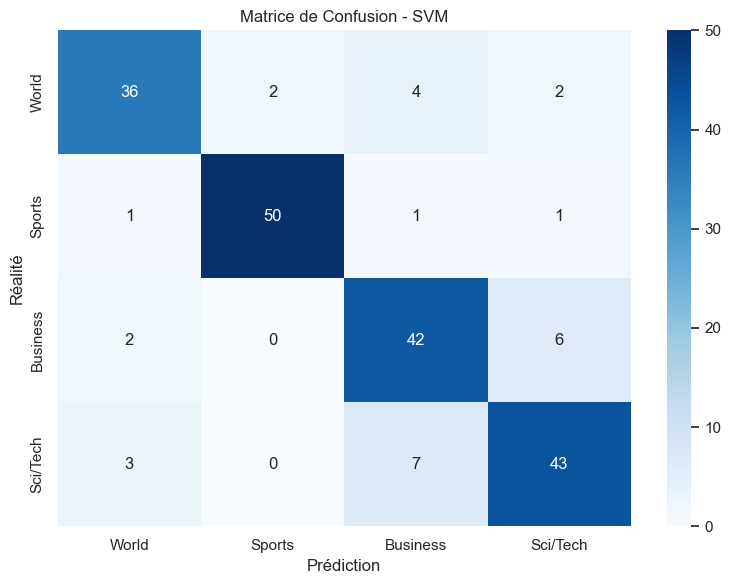

In [21]:
# Évaluation + Vérification Overfitting
best_model = results[best_name]['model']
y_pred = results[best_name]['predictions']
target_names = ['World', 'Sports', 'Business', 'Sci/Tech']

# Classification Report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Overfitting Check
print("=" * 50)
print("🔍 VÉRIFICATION OVERFITTING:")
for name, res in results.items():
    train_acc = accuracy_score(y_train, res['model'].predict(X_train))
    test_acc = res['accuracy']
    gap = train_acc - test_acc
    status = "⚠️ Overfitting" if gap > 0.05 else "✅ OK"
    print(f"{name}: Train={train_acc:.3f} | Test={test_acc:.3f} | Gap={gap:.3f} {status}")

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Matrice de Confusion - {best_name}')
plt.xlabel('Prédiction'); plt.ylabel('Réalité')
plt.tight_layout()
plt.show()

In [22]:
# Sauvegarder le meilleur modèle
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_model, f'{models_dir}/best_classifier.joblib')
print(f"✅ Modèle sauvegardé: {models_dir}/best_classifier.joblib")
print(f"   Prêt pour Streamlit!")

✅ Modèle sauvegardé: ../models/best_classifier.joblib
   Prêt pour Streamlit!
